In [25]:
from src.dataset import load_datasets
train_ds, val_ds, test_ds, classes = load_datasets("../data")
print(classes)

['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito', 'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheesecake', 'cheese_plate', 'chicken_curry', 'chicken_quesadilla', 'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder', 'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame', 'cup_cakes', 'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict', 'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras', 'french_fries', 'french_onion_soup', 'french_toast', 'fried_calamari', 'fried_rice', 'frozen_yogurt', 'garlic_bread', 'gnocchi', 'greek_salad', 'grilled_cheese_sandwich', 'grilled_salmon', 'guacamole', 'gyoza', 'hamburger', 'hot_and_sour_soup', 'hot_dog', 'huevos_rancheros', 'hummus', 'ice_cream', 'lasagna', 'lobster_bisque', 'lobster_roll_sandwich', 'macaroni_and_cheese', 'macarons', 'miso_sou

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

In [27]:
# --- Nombre de classes ---
print(f"Nombre de classes : {len(classes)}")

Nombre de classes : 101


In [20]:
# --- Nombre d'images train/test ---
def count_images(ds):
    return sum(images.shape[0] for images, labels in ds)

n_train = count_images(train_ds)
n_val   = count_images(val_ds)
n_test  = count_images(test_ds)

print(f"Images train : {n_train}")
print(f"Images val   : {n_val}")
print(f"Images test  : {n_test}")

Images train : 60600
Images val   : 15150
Images test  : 25250


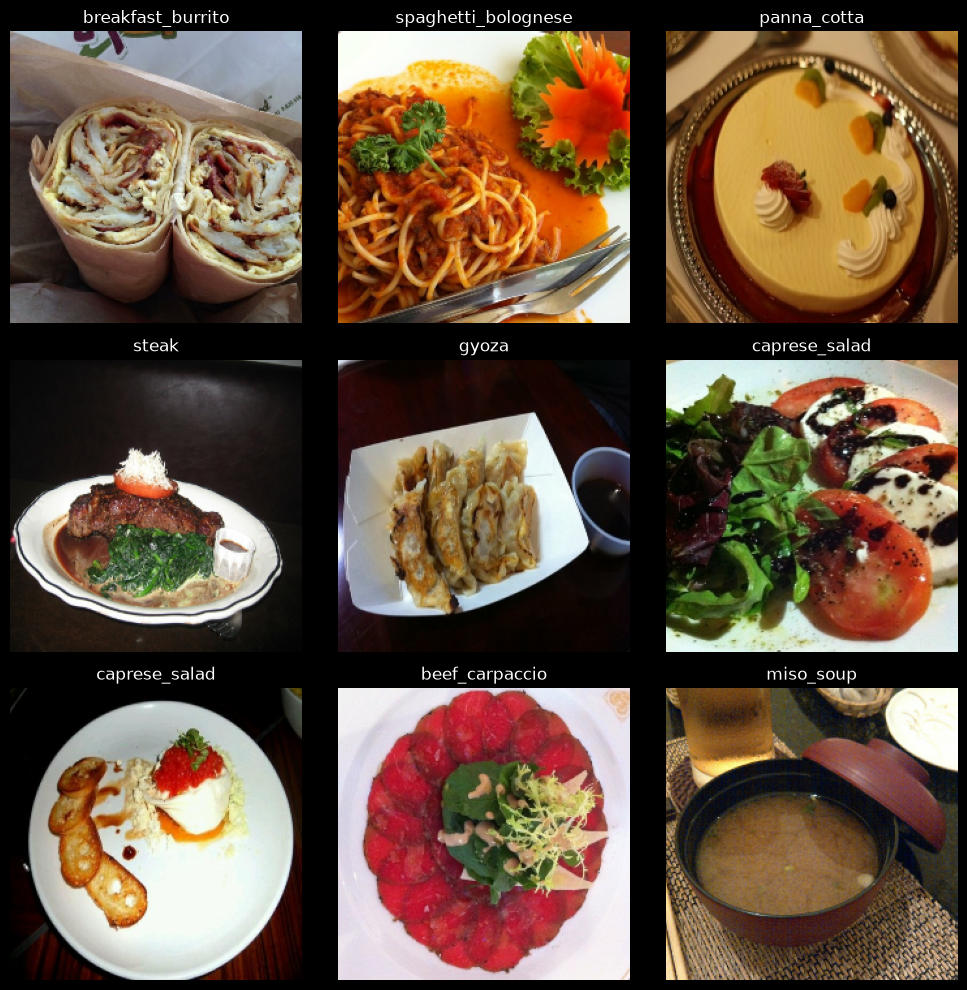

In [21]:
# --- Affichage de plusieurs images aléatoires ---
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    indices = np.random.choice(images.shape[0], size=9, replace=False)
    for i, idx in enumerate(indices):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[idx].numpy())
        plt.title(classes[labels[idx]])
        plt.axis("off")
plt.tight_layout()
plt.show()

In [22]:
# --- Nombre d'images par classe ---
def count_per_class(ds, classes):
    counter = Counter()
    for images, labels in ds:
        for label in labels.numpy():
            counter[classes[label]] += 1
    return counter

train_counts = count_per_class(train_ds, classes)
print("Répartition train :")
for c, n in train_counts.items():
    print(f"  {c}: {n}")

Répartition train :
  panna_cotta: 584
  miso_soup: 606
  cheese_plate: 595
  ceviche: 588
  tiramisu: 614
  lasagna: 572
  spaghetti_carbonara: 618
  breakfast_burrito: 596
  frozen_yogurt: 604
  macarons: 575
  shrimp_and_grits: 611
  bruschetta: 586
  pulled_pork_sandwich: 587
  crab_cakes: 587
  eggs_benedict: 606
  clam_chowder: 609
  garlic_bread: 599
  hot_and_sour_soup: 586
  grilled_salmon: 594
  lobster_roll_sandwich: 594
  sashimi: 618
  french_toast: 598
  pizza: 593
  beignets: 610
  cannoli: 609
  beet_salad: 596
  falafel: 609
  peking_duck: 618
  lobster_bisque: 600
  samosa: 601
  red_velvet_cake: 598
  ice_cream: 595
  baby_back_ribs: 610
  caprese_salad: 586
  hot_dog: 585
  creme_brulee: 618
  beef_carpaccio: 599
  greek_salad: 603
  nachos: 606
  paella: 625
  mussels: 607
  bibimbap: 597
  french_fries: 592
  spring_rolls: 604
  ravioli: 599
  baklava: 611
  strawberry_shortcake: 590
  apple_pie: 606
  pad_thai: 604
  poutine: 593
  chicken_wings: 616
  gnocchi: 6

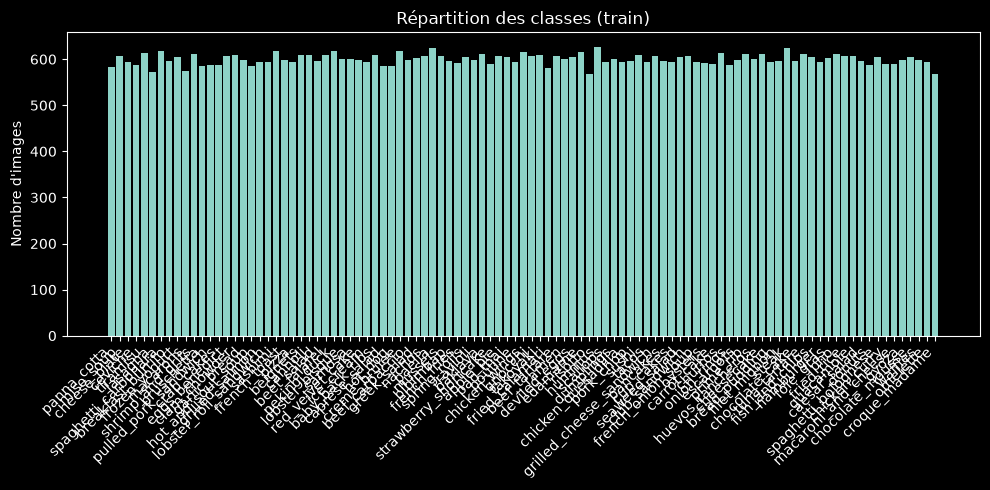

In [23]:
# --- Vérifier l'équilibre du dataset (visuel + statistique) ---
plt.figure(figsize=(10, 5))
plt.bar(train_counts.keys(), train_counts.values())
plt.xticks(rotation=45, ha="right")
plt.ylabel("Nombre d'images")
plt.title("Répartition des classes (train)")
plt.tight_layout()
plt.show()

In [24]:
counts = list(train_counts.values())
mean_count = np.mean(counts)
std_count = np.std(counts)
ratio = max(counts) / min(counts)

print(f"Moyenne par classe : {mean_count:.1f}")
print(f"Écart-type : {std_count:.1f}")
print(f"Ratio max/min : {ratio:.2f}")
if ratio > 1.5:
    print("⚠️ Dataset potentiellement déséquilibré")
else:
    print("✅ Dataset globalement équilibré")

Moyenne par classe : 600.0
Écart-type : 11.4
Ratio max/min : 1.10
✅ Dataset globalement équilibré
